In [4]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data_frame = pd.read_csv('/content/Teen_Mental_Health_Dataset.csv')
data_frame.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


**DATA CLEANING AND DATA BASE OVERVIEW**

In [6]:
#Preserving the Original DF
df = data_frame.copy()

In [7]:
# DF Dimensions
df.shape

(1200, 13)

In [8]:
#Checking Missing Values
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [9]:
# Checking for Duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
# Technical Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [11]:
# No. of Unique Values per Column
df.nunique()

,0
age,7
gender,2
daily_social_media_hours,71
platform_usage,3
sleep_hours,51
screen_time_before_sleep,26
academic_performance,201
physical_activity,21
social_interaction_level,3
stress_level,10


In [12]:
# Ranges
print('MAX')
display(df.max())
print('\nMIN')
display(df.min())

MAX


,0
age,19
gender,male
daily_social_media_hours,8.0
platform_usage,TikTok
sleep_hours,9.0
screen_time_before_sleep,3.0
academic_performance,4.0
physical_activity,2.0
social_interaction_level,medium
stress_level,10



MIN


,0
age,13
gender,female
daily_social_media_hours,1.0
platform_usage,Both
sleep_hours,4.0
screen_time_before_sleep,0.5
academic_performance,2.0
physical_activity,0.0
social_interaction_level,high
stress_level,1


In [13]:
# Statistical Overview
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


**ANALYSIS AND VISUALIZATION**

1. Average Daily Social Media Usage by Gender

In [14]:
#1. Analysis
avg_time_by_gender = df.groupby('gender')['daily_social_media_hours'].mean().reset_index()
avg_time_by_gender

,gender,daily_social_media_hours
0,female,4.512991
1,male,4.559187


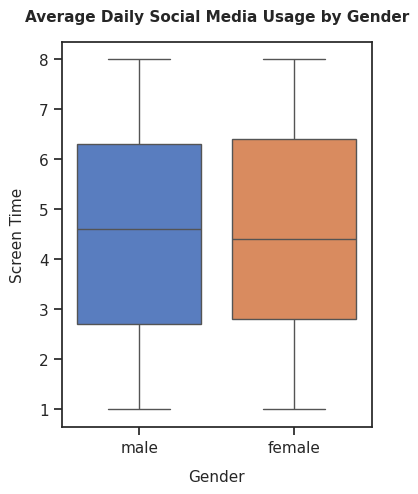

In [15]:
#1. Graph: Boxplot
sns.set_theme(style='ticks')
plt.figure(figsize=(4, 5))
sns.boxplot(data=df, x='gender', y='daily_social_media_hours', hue='gender', palette='muted')

plt.title('Average Daily Social Media Usage by Gender', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Gender', fontsize=11, labelpad=10)
plt.ylabel('Screen Time', fontsize=11, labelpad=10)

plt.show()

2. Average Time in Social Media by Age and Gender

In [16]:
#2. Analysis
avg_time_by_age = df.groupby(['gender', 'age'])['daily_social_media_hours'].mean().reset_index()
avg_time_by_age

,gender,age,daily_social_media_hours
0,female,13,4.311828
1,female,14,4.314103
2,female,15,4.492135
3,female,16,4.796104
4,female,17,4.729897
5,female,18,4.244444
6,female,19,4.727143
7,male,13,4.684112
8,male,14,4.389333
9,male,15,4.937363


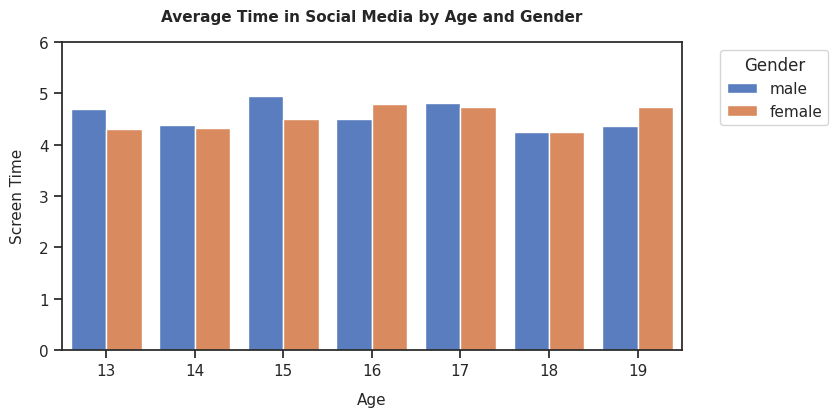

In [17]:
# 2. Graph: Barplot
sns.set_theme(style='ticks')
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='age', y='daily_social_media_hours', hue='gender', palette='muted', errorbar=None)

plt.title('Average Time in Social Media by Age and Gender', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=11, labelpad=10)
plt.ylabel('Screen Time', fontsize=11, labelpad=10)
plt.ylim(0, 6)
plt.legend(title='Gender', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

3. Average Time per Platform by Age

In [18]:
#3. Analysis
avg_time_by_platform = df.groupby(['age','platform_usage'])['daily_social_media_hours'].mean().reset_index()
avg_time_by_platform

,age,platform_usage,daily_social_media_hours
0,13,Both,4.547619
1,13,Instagram,4.721429
2,13,TikTok,4.256716
3,14,Both,3.812500
4,14,Instagram,4.750000
5,14,TikTok,4.408511
6,15,Both,5.130000
7,15,Instagram,4.340625
8,15,TikTok,4.705357
9,16,Both,4.600000


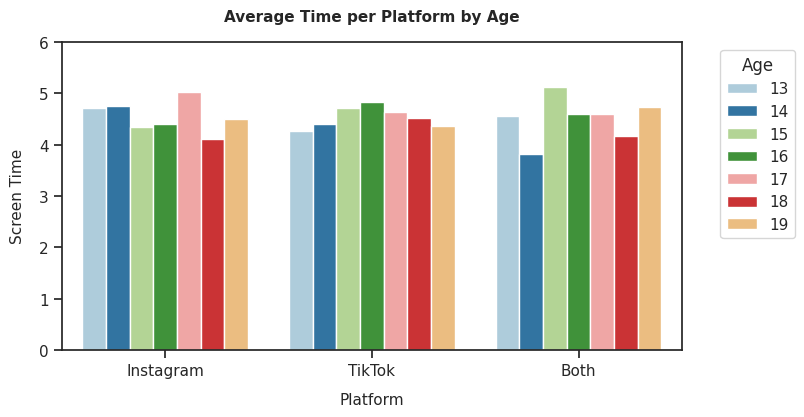

In [19]:
#3. Graph: Barplot
sns.set_theme(style='ticks')
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='platform_usage', y='daily_social_media_hours', hue='age', palette='Paired', errorbar=None)

plt.title('Average Time per Platform by Age', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Platform', fontsize=11, labelpad=10)
plt.ylabel('Screen Time', fontsize=11, labelpad=10)
plt.ylim(0, 6)
plt.legend(title='Age', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

4. Sleep Patterns: Distribution by Age and Gender

In [20]:
#4. Analysis
avg_time_sleep_by_age_and_gender = df.groupby(['age', 'gender'])['sleep_hours'].mean().reset_index()
avg_time_sleep_by_age_and_gender

,age,gender,sleep_hours
0,13,female,6.873118
1,13,male,6.148598
2,14,female,6.247436
3,14,male,6.386667
4,15,female,6.670787
5,15,male,6.320879
6,16,female,6.358442
7,16,male,6.600000
8,17,female,6.522680
9,17,male,6.483562


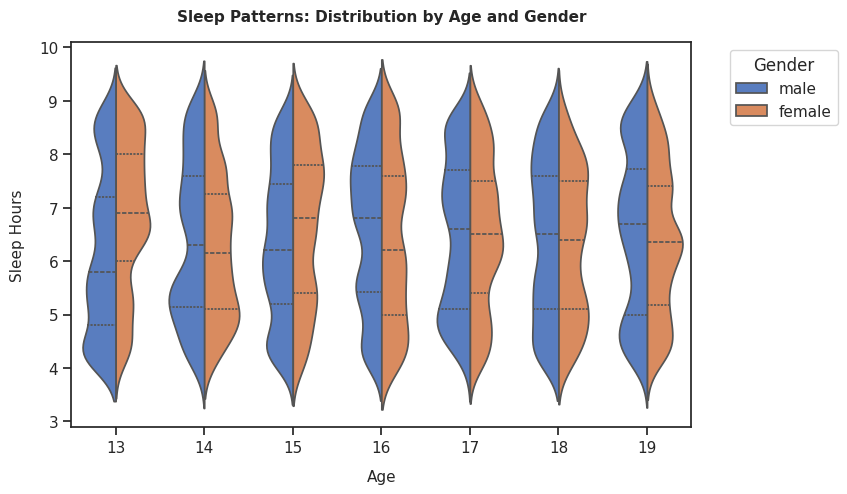

In [21]:
#4. Graph: Violin Plot
sns.set_theme(style='ticks')
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='age', y='sleep_hours', hue='gender', split=True, inner="quart", palette='muted', bw_adjust=0.6)

plt.title('Sleep Patterns: Distribution by Age and Gender', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=11, labelpad=10)
plt.ylabel('Sleep Hours', fontsize=11, labelpad=10)
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

5. Social Media Usage vs. Sleep Hours

In [22]:
#5. Analysis
df['time_group'] = pd.cut(
    df['daily_social_media_hours'],
    bins=[0,2,4,6,8],
    labels=['0-2h', '2-4h', '4-6h','6h-8h'],
    include_lowest=True)
avg_time_sleep_by_sm_time = df.groupby(['gender', 'time_group'], observed=False)['sleep_hours'].mean().reset_index()
avg_time_sleep_by_sm_time

,gender,time_group,sleep_hours
0,female,0-2h,6.851807
1,female,2-4h,6.387709
2,female,4-6h,6.430818
3,female,6h-8h,6.498780
4,male,0-2h,6.279775
5,male,2-4h,6.390395
6,male,4-6h,6.407910
7,male,6h-8h,6.480814


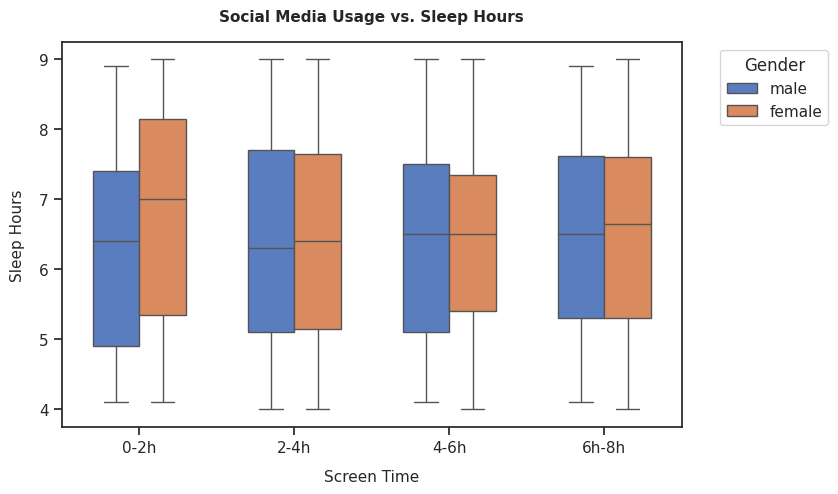

In [23]:
#5. Graph: Boxplot
sns.set_theme(style='ticks')
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='time_group', y='sleep_hours', hue='gender', palette='muted', width=0.6)

plt.title('Social Media Usage vs. Sleep Hours', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Screen Time', fontsize=11, labelpad=10)
plt.ylabel('Sleep Hours', fontsize=11, labelpad=10)
plt.legend(title='Gender', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

6. Stress Scale by Exposure Time

In [24]:
#6. Analysis
stress = df.groupby(['time_group','gender'], observed=False)['stress_level'].mean().reset_index()
stress

,time_group,gender,stress_level
0,0-2h,female,5.337349
1,0-2h,male,5.865169
2,2-4h,female,5.223464
3,2-4h,male,5.305085
4,4-6h,female,5.238994
5,4-6h,male,5.231638
6,6h-8h,female,5.859756
7,6h-8h,male,5.674419


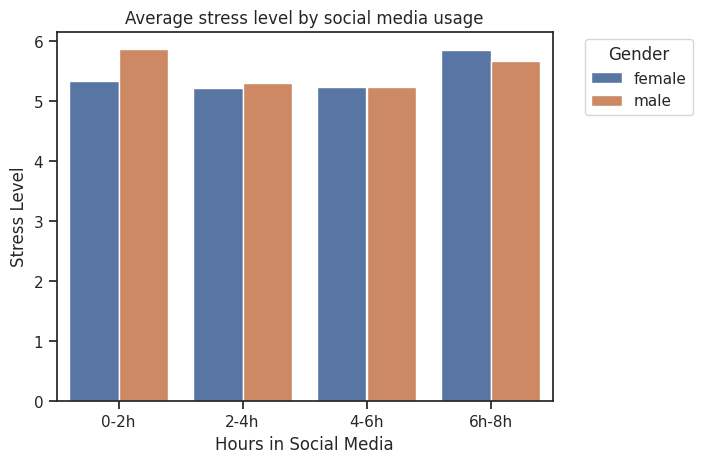

In [25]:
#6. Graph
sns.set(style='ticks')
sns.barplot(data=stress, x='time_group', y='stress_level', hue='gender')

plt.title('Average stress level by social media usage')
plt.xlabel('Hours in Social Media')
plt.ylabel('Stress Level')
plt.legend(title='Gender', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

7. Evening Screen Exposure vs. Stress Level



In [26]:
#7. Analysis
df['screen_time'] = pd.cut(
    df['screen_time_before_sleep'],
    bins=[0, 0.5, 1, 1.5, 2, 2.5, 3],
    labels=['0-0h30', '0h30-1h', '1h-1h30', '1h30-2h', '2h-2h30', '2h30-3h'],
    include_lowest=True)
stress_evening = df.groupby('screen_time')['stress_level'].mean().reset_index()
stress_evening

/tmp/ipykernel_1559/1240816855.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_evening = df.groupby('screen_time')['stress_level'].mean().reset_index()


,screen_time,stress_level
0,0-0h30,5.296296
1,0h30-1h,5.450644
2,1h-1h30,5.389961
3,1h30-2h,5.652720
4,2h-2h30,5.550000
5,2h30-3h,5.163366


8. Social Interaction vs. Digital World

In [27]:
#8. Analysis
social_activity_daily_sm = df.groupby('social_interaction_level')['daily_social_media_hours'].mean().reset_index()
social_activity_daily_sm

,social_interaction_level,daily_social_media_hours
0,high,4.457182
1,low,4.539518
2,medium,4.604327


9. Social Interaction vs. Well-being

In [28]:
#9. Analysis
social_activity_stress_level = df.groupby('social_interaction_level')['stress_level'].mean().reset_index()
social_activity_stress_level

,social_interaction_level,stress_level
0,high,5.512195
1,low,5.349398
2,medium,5.483173


10. Depression Level vs. Time in Social Media

In [29]:
#10. Analysis
avg_depression_lvl = df.groupby(['gender', 'time_group'], observed=False)['depression_label'].mean().reset_index()
avg_depression_lvl

,gender,time_group,depression_label
0,female,0-2h,0.000000
1,female,2-4h,0.000000
2,female,4-6h,0.031447
3,female,6h-8h,0.073171
4,male,0-2h,0.000000
5,male,2-4h,0.000000
6,male,4-6h,0.022599
7,male,6h-8h,0.058140


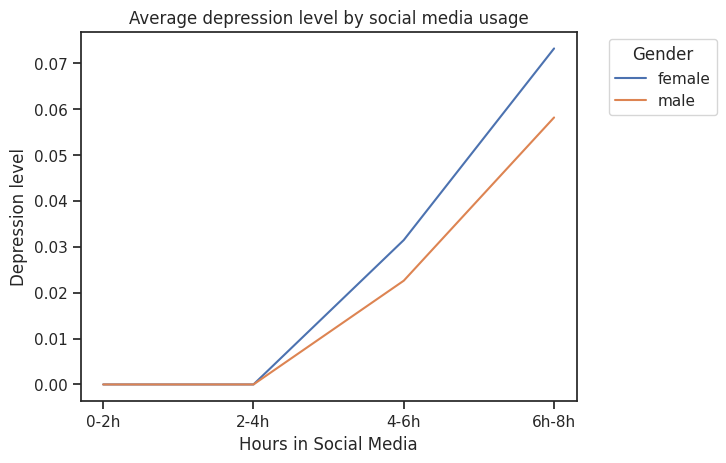

In [30]:
#10. Graph
sns.set(style='ticks')
sns.lineplot(data=avg_depression_lvl, x='time_group', y='depression_label', hue='gender')

plt.title('Average depression level by social media usage')
plt.xlabel('Hours in Social Media')
plt.ylabel('Depression level')
plt.legend(title='Gender', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

11. Addiction Level vs. Time in Social Media

In [31]:
#11. Analysis
avg_addiction_lvl = df.groupby(['time_group', 'gender', 'age'], observed=False)['addiction_level'].mean().reset_index()
avg_addiction_lvl

,time_group,gender,age,addiction_level
0,0-2h,female,13,5.307692
1,0-2h,female,14,5.058824
2,0-2h,female,15,6.142857
3,0-2h,female,16,4.833333
4,0-2h,female,17,4.909091
5,0-2h,female,18,5.363636
6,0-2h,female,19,7.000000
7,0-2h,male,13,7.538462
8,0-2h,male,14,6.555556
9,0-2h,male,15,4.333333


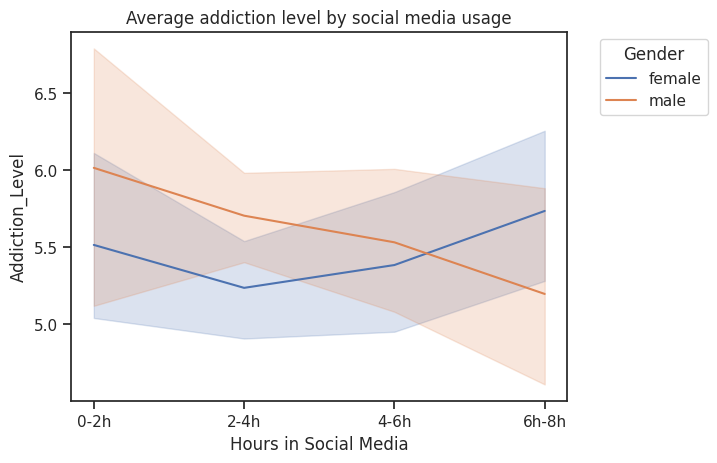

In [32]:
#11. Graph
sns.set(style='ticks')
sns.lineplot(data=avg_addiction_lvl, x='time_group', y='addiction_level', hue='gender')

plt.title('Average addiction level by social media usage')
plt.xlabel('Hours in Social Media')
plt.ylabel('Addiction_Level')
plt.legend(title='Gender', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

12. Stress Level influenciated by type of Platform

In [33]:
#12. Analysis
avg_platform_stress = df.groupby(['platform_usage', 'gender'])['stress_level'].mean().reset_index()
avg_platform_stress

,platform_usage,gender,stress_level
0,Both,female,5.550265
1,Both,male,5.549505
2,Instagram,female,5.453202
3,Instagram,male,5.543269
4,TikTok,female,5.264249
5,TikTok,male,5.312195


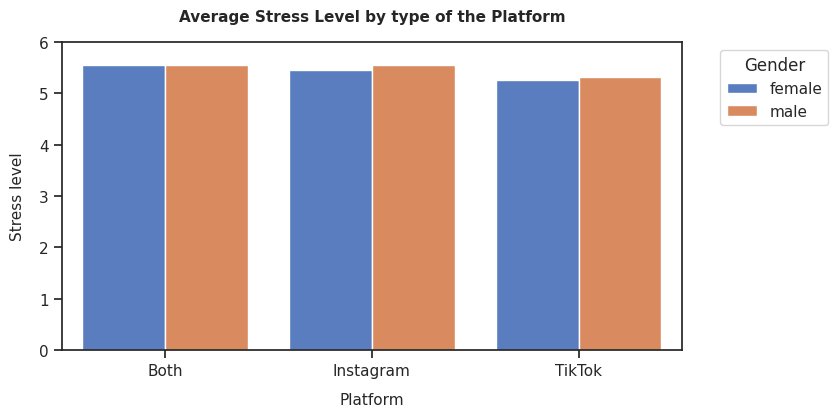

In [34]:
#12. Graph
sns.set_theme(style='ticks')
plt.figure(figsize=(8, 4))
sns.barplot(data=avg_platform_stress, x='platform_usage', y='stress_level', hue='gender', palette='muted')

plt.title('Average Stress Level by type of the Platform', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Platform', fontsize=11, labelpad=10)
plt.ylabel('Stress level', fontsize=11, labelpad=10)
plt.ylim(0, 6)
plt.legend(title='Gender', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

13. Social Activity impact on Depression Level

In [35]:
#13. Analysis
avg_depression_social_activity = df.groupby(['social_interaction_level', 'gender'])['depression_label'].mean().reset_index()
avg_depression_social_activity

,social_interaction_level,gender,depression_label
0,high,female,0.031250
1,high,male,0.022599
2,low,female,0.030612
3,low,male,0.013699
4,medium,female,0.025381
5,medium,male,0.031963


14. Physical Activity impact on Depression Level

In [36]:
#14. Analysis
df['physical_activity_group'] = pd.qcut(
    df['physical_activity'],
    q=3,
    labels=['Low','Medium','High'],
)
avg_depression_physical_activity = df.groupby(['physical_activity_group', 'gender'], observed=False)['depression_label'].mean().reset_index()
avg_depression_physical_activity['depression_label'] *= 100
avg_depression_physical_activity

,physical_activity_group,gender,depression_label
0,Low,female,3.652968
1,Low,male,1.435407
2,Medium,female,3.428571
3,Medium,male,3.045685
4,High,female,1.570681
5,High,male,2.392344


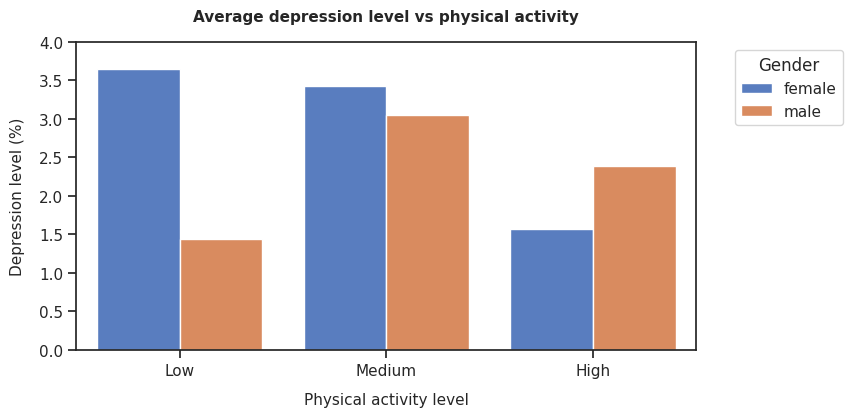

In [37]:
#14. Graph Barplot
sns.set_theme(style='ticks')
plt.figure(figsize=(8, 4))
sns.barplot(data=avg_depression_physical_activity, x='physical_activity_group', y='depression_label', hue='gender', palette='muted')

plt.title('Average depression level vs physical activity', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Physical activity level', fontsize=11, labelpad=10)
plt.ylabel('Depression level (%)', fontsize=11, labelpad=10)
plt.ylim(0, 4)
plt.legend(title='Gender', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

15. Screen Time before Sleep vs. Sleep Hours

In [38]:
#15. Analysis
time_sleep_social_media_befor_sleep = df.groupby(['screen_time', 'gender'], observed=False)['sleep_hours'].mean().reset_index()
time_sleep_social_media_befor_sleep

,screen_time,gender,sleep_hours
0,0-0h30,female,6.600000
1,0-0h30,male,5.678571
2,0h30-1h,female,6.491089
3,0h30-1h,male,6.353030
4,1h-1h30,female,6.730534
5,1h-1h30,male,6.295312
6,1h30-2h,female,6.420492
7,1h30-2h,male,6.677778
8,2h-2h30,female,6.291667
9,2h-2h30,male,6.473333


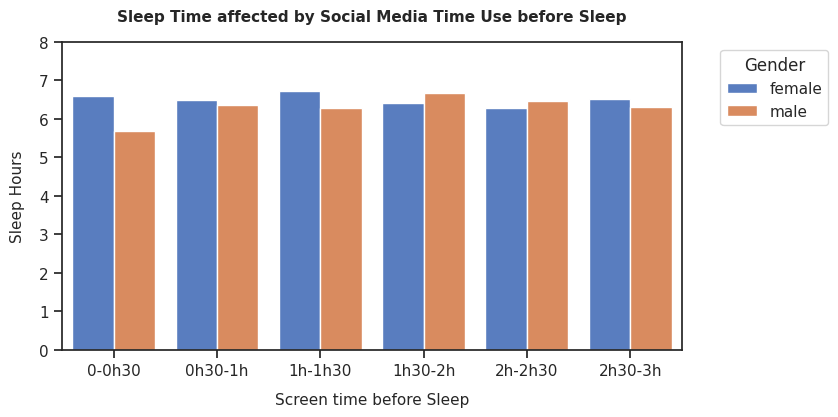

In [39]:
#15. Graph Barplot
sns.set_theme(style='ticks')
plt.figure(figsize=(8, 4))
sns.barplot(data=time_sleep_social_media_befor_sleep, x='screen_time', y='sleep_hours', hue='gender', palette='muted')

plt.title('Sleep Time affected by Social Media Time Use before Sleep', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Screen time before Sleep', fontsize=11, labelpad=10)
plt.ylabel('Sleep Hours', fontsize=11, labelpad=10)
plt.ylim(0, 8)
plt.legend(title='Gender', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

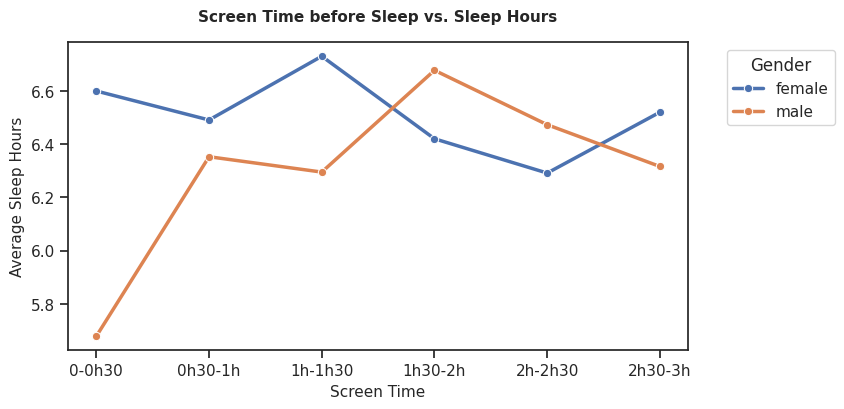

In [40]:
#15. Graph: Lineplot
sns.set_theme(style='ticks')
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=time_sleep_social_media_befor_sleep, x='screen_time', y='sleep_hours', hue='gender', marker='o', linewidth=2.5)

plt.title('Screen Time before Sleep vs. Sleep Hours', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Screen Time', fontsize=11)
plt.ylabel('Average Sleep Hours', fontsize=11)
plt.legend(title='Gender', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

16. Anxiety Levels by Daily Social Media Usage and Gender

In [41]:
#16. Analysis
avg_anxiety = df.groupby(['time_group', 'gender'], observed=False)['anxiety_level'].mean().reset_index()
avg_anxiety

,time_group,gender,anxiety_level
0,0-2h,female,5.433735
1,0-2h,male,5.146067
2,2-4h,female,5.972067
3,2-4h,male,5.497175
4,4-6h,female,5.754717
5,4-6h,male,5.785311
6,6h-8h,female,5.439024
7,6h-8h,male,5.709302


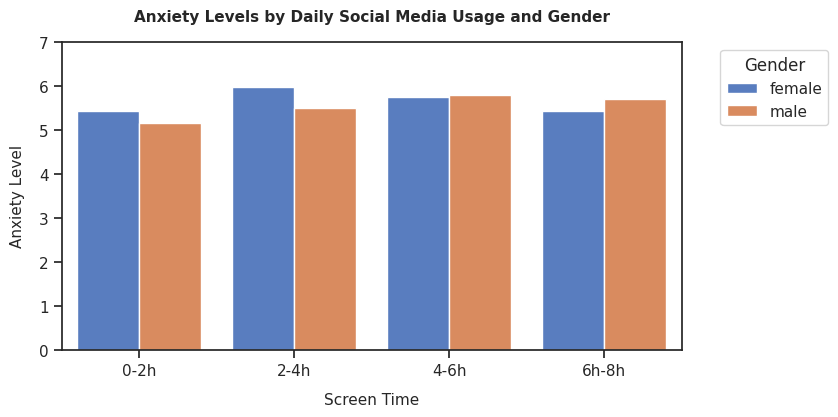

In [42]:
#16. Graph: Barplot
sns.set_theme(style='ticks')
plt.figure(figsize=(8, 4))
sns.barplot(data=avg_anxiety, x='time_group', y='anxiety_level', hue='gender', palette='muted')

plt.title('Anxiety Levels by Daily Social Media Usage and Gender', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Screen Time', fontsize=11, labelpad=10)
plt.ylabel('Anxiety Level', fontsize=11, labelpad=10)
plt.ylim(0, 7)
plt.legend(title='Gender', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

17. Average Academic Performance by Daily Social Media Usage and Gender

In [43]:
#17. Analysis:
avg_academic_time_sm = df.groupby(['gender', 'time_group'], observed=False)['academic_performance'].mean().reset_index()
avg_academic_time_sm

,gender,time_group,academic_performance
0,female,0-2h,3.021928
1,female,2-4h,2.988324
2,female,4-6h,2.951006
3,female,6h-8h,3.051098
4,male,0-2h,3.021348
5,male,2-4h,2.984576
6,male,4-6h,2.942203
7,male,6h-8h,2.995349
